# 04. Оценка результатов и итоговое сравнение
1. **Реконструкция** - $MSE/MAE/R^2$ на тесте.
2. **Полезность эмбеддингов** - линейный зонд z->y(t+H) (регрессия), silhouette по режимам, **классификация** (логрег z->класс), если включена.
3. **Структура/устойчивость** - коэффициент коллапса $\mu$, $F1$ обнаружения аномалий.

In [10]:
import sys, pathlib
for cand in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    src = cand / "src"
    if src.exists():
        sys.path.insert(0, str(src))
        break

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)
ROOT = pathlib.Path.cwd().parent
ROOT

WindowsPath('e:/SSAU_code/НИР')

In [ ]:
import pickle, pathlib
results_dir = ROOT / "results" / "2026-08-08"

with open(results_dir / "run_config.pkl", "rb") as f:
    run_cfg = pickle.load(f)

DATA_SOURCE = run_cfg["DATA_SOURCE"]
RUN_CLASSIFICATION_TASK = run_cfg["RUN_CLASSIFICATION_TASK"]
WINDOW_LEN = run_cfg["WINDOW_LEN"]
LOG_TRANSFORM = run_cfg.get("LOG_TRANSFORM", False)
print(run_cfg)


{'DATA_SOURCE': 'csv_recession', 'RUN_CLASSIFICATION_TASK': True, 'PRICE_CSV_PATH': '../data/raw/aapl.csv', 'PRICE_DATE_COL': 'Date', 'VALUE_COLS': None, 'USREC_CSV_PATH': '../data/raw/USREC.csv', 'SERIES_LENGTH': 3000, 'WINDOW_LEN': 48, 'EPOCHS': 20, 'LOG_TRANSFORM': True}


In [14]:
from tsprep.config import DataConfig
from tsprep.data_preprocessing.datasets import prepare_and_window, build_dataloaders, build_eval_loader, chronological_split_indices, sliding_windows

if DATA_SOURCE == "synthetic":
    from tsprep.data_preprocessing.synthetic import generate_series
    series = generate_series(length=run_cfg["SERIES_LENGTH"], n_features=1, n_regimes=3, anomaly_rate=0.01, seed=42)
    raw, regime, is_anomaly = series.values, series.regime, series.is_anomaly
elif DATA_SOURCE == "csv_recession":
    from tsprep.data_preprocessing.loaders import load_series_with_recession_labels
    bundle = load_series_with_recession_labels(
        price_path=run_cfg["PRICE_CSV_PATH"], label_path=run_cfg["USREC_CSV_PATH"],
        price_date_col=run_cfg["PRICE_DATE_COL"], value_cols=run_cfg["VALUE_COLS"],
        label_date_col="observation_date",   # для старого формата FRED (fredgraph.csv) поставьте "DATE"
    )
    raw, regime, is_anomaly = bundle["values"], bundle["labels"], None
else:
    raise ValueError(DATA_SOURCE)

data_cfg = DataConfig(window_len=WINDOW_LEN, n_features=raw.shape[1], batch_size=64,
                       log_transform=LOG_TRANSFORM)
prepared = prepare_and_window(raw, data_cfg, regime=regime, is_anomaly=is_anomaly)
train_loader, val_loader, test_loader = build_dataloaders(prepared, data_cfg)

n = prepared.raw_normalized.shape[0] # type: ignore
train_end, val_end = chronological_split_indices(n, data_cfg.train_frac, data_cfg.val_frac, data_cfg.test_frac)

regime_label_test = None
if prepared.regime is not None:
    regime_windows = sliding_windows(prepared.regime[val_end:].reshape(-1, 1), WINDOW_LEN, data_cfg.stride)
    regime_label_test = regime_windows[:, -1, 0].astype(int)

anomaly_label_test = None
if prepared.is_anomaly is not None:
    from tsprep.evaluation.downstream import window_anomaly_labels
    anomaly_label_test = window_anomaly_labels(prepared.is_anomaly[val_end:], WINDOW_LEN, data_cfg.stride, prepared.test_windows.shape[0])

print("test windows:", prepared.test_windows.shape[0], "| RUN_CLASSIFICATION_TASK:", RUN_CLASSIFICATION_TASK, "| LOG_TRANSFORM:", LOG_TRANSFORM)


test windows: 957 | RUN_CLASSIFICATION_TASK: True | LOG_TRANSFORM: True


In [5]:
from tsprep.config import ModelConfig, ALL_MODEL_NAMES
from tsprep.models.autoencoder import build_model
import torch

models = {}
for name in ALL_MODEL_NAMES:
    model_cfg = ModelConfig(model_name=name, latent_dim=16, hidden_dim=48,
                             tcn_levels=4, d_model=48, n_heads=4, n_attn_layers=2)
    model = build_model(model_cfg, n_features=data_cfg.n_features, window_len=WINDOW_LEN)
    state_path = results_dir / f"model_{name}.pt"
    if state_path.exists():
        model.load_state_dict(torch.load(state_path, map_location="cpu"))
        print(f"loaded {name} from {state_path.name}")
    else:
        print(f"[!] {state_path} not found - run notebook 03 first (using randomly-initialized {name})")
    models[name] = model


loaded tcn_ae from model_tcn_ae.pt
loaded tcn_vae from model_tcn_vae.pt
loaded lstm_ae from model_lstm_ae.pt
loaded lstm_vae from model_lstm_vae.pt
loaded transformer_ae from model_transformer_ae.pt
loaded hybrid_vae from model_hybrid_vae.pt


## Сводная таблица

In [ ]:
from tsprep.evaluation.reconstruction import collect_embeddings, reconstruction_report
from tsprep.evaluation.downstream import (forecast_via_linear_probe, clustering_quality,
                                           anomaly_detection_f1, classify_via_linear_probe,
                                           window_class_labels)
from tsprep.evaluation.latent_space import information_collapse_ratio
from tsprep.evaluation.visualize import comparison_table

results = {}
h = data_cfg.forecast_horizon
step = max(1, h // max(1, data_cfg.stride))

# метки классификации на уровне окон (нужны один раз, одинаковы для всех моделей)
class_label_train = class_label_test = None
if RUN_CLASSIFICATION_TASK and prepared.regime is not None:
    class_label_train = window_class_labels(prepared.regime[:train_end], WINDOW_LEN, data_cfg.stride,
                                             prepared.train_windows.shape[0], rule="last")
    class_label_test = window_class_labels(prepared.regime[val_end:], WINDOW_LEN, data_cfg.stride,
                                            prepared.test_windows.shape[0], rule="last")
    print("class balance | train positive rate:", class_label_train.mean(),
          "test positive rate:", class_label_test.mean())

train_eval_loader = build_eval_loader(prepared.train_windows, data_cfg.batch_size)
for name, model in models.items():
    test_out = collect_embeddings(model, test_loader)
    train_out = collect_embeddings(model, train_eval_loader)
    recon = reconstruction_report(test_out["x"], test_out["x_hat"])
    eta = information_collapse_ratio(test_out["z"], test_out["x"])

    n_tr, n_te = train_out["z"].shape[0] - step, test_out["z"].shape[0] - step
    fc = forecast_via_linear_probe(
        train_out["z"][:n_tr], train_out["x"][step:step + n_tr, -1, 0],
        test_out["z"][:n_te], test_out["x"][step:step + n_te, -1, 0],
    ) if n_tr > 10 and n_te > 10 else {"mae": float("nan"), "r2": float("nan")}

    row = {
        "mse": recon["mse"], "mae": recon["mae"], "r2": recon["r2"],
        "eta_collapse": eta,
        "forecast_mae": fc["mae"], "forecast_r2": fc["r2"],
    }

    if regime_label_test is not None:
        row["silhouette"] = clustering_quality(test_out["z"], labels=regime_label_test)["silhouette"]
    if anomaly_label_test is not None:
        row["anomaly_f1"] = anomaly_detection_f1(test_out["x"], test_out["x_hat"], anomaly_label_test)["f1"]

    if RUN_CLASSIFICATION_TASK and class_label_train is not None:
        assert class_label_test is not None, "class_label_test is None but RUN_CLASSIFICATION_TASK is True"
        clf_metrics = classify_via_linear_probe(
            train_out["z"], class_label_train, test_out["z"], class_label_test,
        )
        row["class_accuracy"] = clf_metrics["accuracy"]
        row["class_f1"] = clf_metrics["f1"]
        row["class_roc_auc"] = clf_metrics["roc_auc"]

    results[name] = row

table = comparison_table(results)
table


class balance | train positive rate: 0.11717738454898576 test positive rate: 0.0


,mse,mae,r2,eta_collapse,forecast_mae,forecast_r2,silhouette,class_accuracy,class_f1,class_roc_auc
tcn_ae,0.451173,0.470864,0.035025,2.644913e-03,0.433855,-0.001095,0.310041,0.965517,0.0,NaN
transformer_ae,0.462306,0.476774,0.011212,3.099861e-03,0.435682,-0.004492,0.507142,0.965517,0.0,NaN
lstm_ae,0.467666,0.478295,-0.000251,3.188614e-06,0.439618,-0.022690,0.295866,0.763845,0.0,NaN
lstm_vae,0.467675,0.478449,-0.000270,5.227956e-07,0.438112,-0.021035,0.200744,0.872518,0.0,NaN
tcn_vae,0.469575,0.480596,-0.004335,1.405393e-05,0.435222,-0.010012,0.290976,0.951933,0.0,NaN
hybrid_vae,0.470802,0.481209,-0.006958,7.635543e-05,0.434544,-0.006399,0.271254,0.885057,0.0,NaN


In [16]:
table.to_csv(results_dir / "comparison_table.csv")
print("saved:", (results_dir / "comparison_table.csv").resolve())

saved: E:\SSAU_code\НИР\results\2026-08-08\comparison_table.csv


## Примеры реконструкции (лучшая по MSE модель)

In [ ]:
from tsprep.evaluation.visualize import plot_reconstruction_examples, plot_latent_projection
from tsprep.evaluation.latent_space import pca_project

best_name = table.index[0]
best_out = collect_embeddings(models[best_name], test_loader)
fig = plot_reconstruction_examples(best_out["x"], best_out["x_hat"], n_examples=4)
print("best model by MSE:", best_name)

## Латентное пространство: PCA-проекция
Окраска по скрытому режиму (synthetic) или по метке рецессии (csv_recession), если она есть.

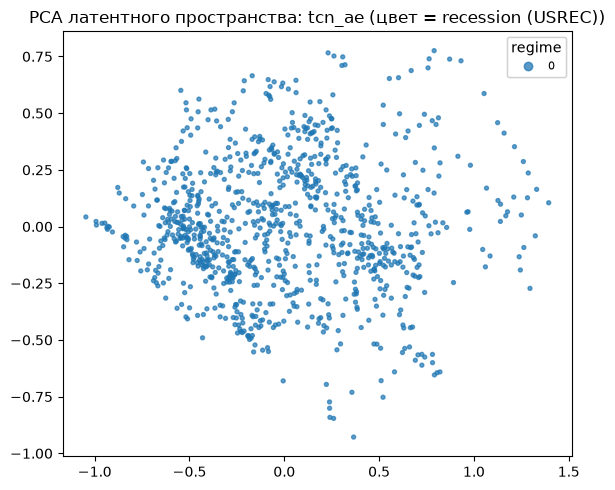

In [18]:
proj = pca_project(best_out["z"], n_components=2)
color_labels = regime_label_test if regime_label_test is not None else class_label_test
label_name = "regime" if DATA_SOURCE == "synthetic" else "recession (USREC)"
fig = plot_latent_projection(proj, labels=color_labels, title=f"PCA латентного пространства: {best_name} (цвет = {label_name})")


## Интерпретация

- **$\mu$ (information collapse ratio)** близкий к нулю означает, что модель почти не использует латентное пространство (типичный симптом при избыточно большом `beta` VAE-потери) - сравните VAE- и не-VAE-варианты одной и той же архитектуры (`tcn_ae` vs `tcn_vae`, `lstm_ae` vs `lstm_vae`).
- **forecast_mae** - насколько эмбеддинг полезен для простого линейного прогноза; сравнение с MAE наивного прогноза (`y_t`) даёт представление, добавляет ли модель прогностическую ценность сверх тривиального.
- **silhouette** - насколько хорошо эмбеддинг разделяет скрытые рыночные режимы без явного обучения на этой задаче.
- **class_accuracy / class_f1 / class_roc_auc** (только при `RUN_CLASSIFICATION_TASK=True`) - способность  классификатора отличить рецессию от экспансии по эмбеддингу окна; из-за дисбаланса классов (рецессии - меньшинство времени) accuracy сама по себе может вводить в заблуждение, ориентируйтесь на f1/roc_auc.
- **anomaly_f1** - качество unsupervised-обнаружения внесённых аномалий по композитному скору реконструкции (доступно только на synthetic).

Абсолютные значения $R^2/MSE$ на дифференцированных финансовых рядах обычно невысоки - основной интерес представляет **относительное** сравнение архитектур в таблице выше.